# Exploration and processing

The previous notebook turned a pile of files into a couple of master files.
Those can be shared with the whole team, and they are the starting point for
any actual work. This notebook is that work: select, look, process.

In [1]:
import numpy as np

import xdas as xd

In [2]:
da = xd.open("outputs/singlecable.nc")
da

<xdas.DataArray (time: 37500, distance: 10000)>
VirtualSource: 715.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

## Selection

`sel` selects by coordinate value, `isel` by index. They compose, so
"4000 samples starting at that instant" reads directly:

In [3]:
da = da.sel(time=slice("2023-11-03T12:26:40", None))  # everything after
da = da.isel(time=slice(None, 4000))  # then the first 4000 samples
da.to_netcdf("outputs/event.nc")  # keep it for the next notebook
da

<xdas.DataArray (time: 4000, distance: 10000)>
VirtualSource: 76.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:43.992
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

## Visualization

A data array carries its own coordinates, so it knows how to draw itself:

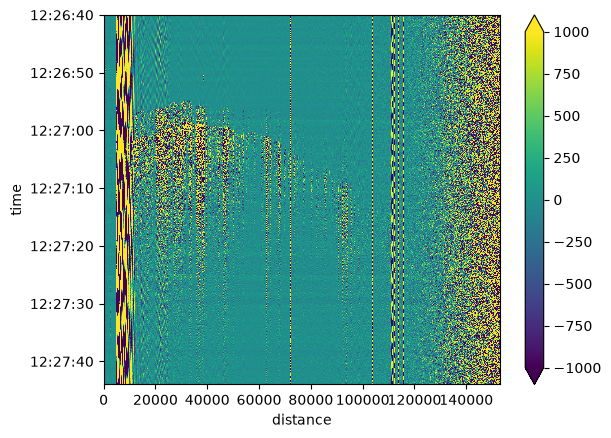

In [4]:
da.plot(yincrease=False, vmin=-1000, vmax=1000)

## Basic processing

Most numpy functions work on a data array directly, and reductions take a
dimension by name. Either way the coordinates come through:

In [5]:
np.abs(da).mean("time")

<xdas.DataArray (distance: 10000)>
[6718.4985  6720.777     93.08875 ... 2549.169   2838.1185  2785.14575]
Coordinates:
  * distance (distance): 0.000 to 153179.709
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

Arithmetic works too, with Xdas checking that dimensions and coordinates
agree. Subtracting the mean of a band of channels removes their common mode:

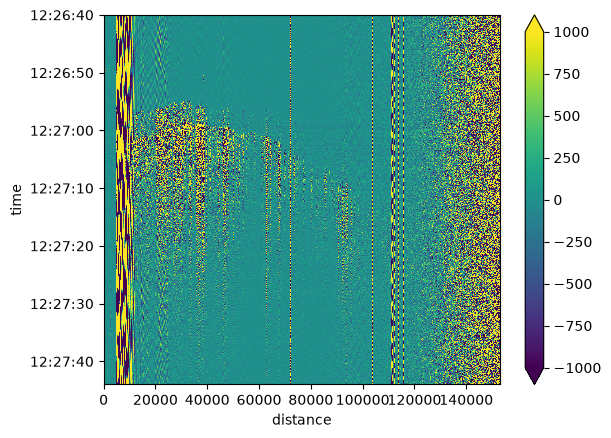

In [6]:
common = da.sel(distance=slice(30_000, 70_000)).mean("distance")
(da - common).plot(yincrease=False, vmin=-1000, vmax=1000)

## Signal processing

Xdas wraps much of `scipy.signal` in `xdas.signal`, but the curated functions
of the main module are the ones to reach for: they take only physical
quantities — a rate in Hz, a corner frequency in Hz, a window length in
seconds or metres. Such a parameter keeps its meaning when the sampling rate
changes, so the same pipeline can be handed a different acquisition, or a
chunk that has already been resampled, and still do what you meant.

Filtering asks for corner frequencies in Hz — `(low, high)`, with `None`
opening one end:

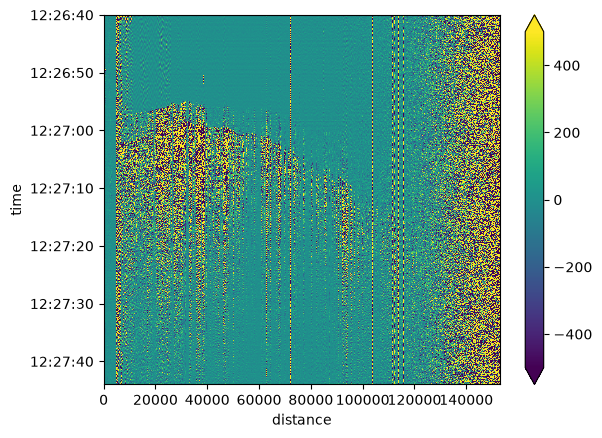

In [7]:
filtered = xd.filter(da, (1.0, 10.0), dim="time")  # bandpass 1-10 Hz
filtered.plot(yincrease=False, vmin=-500, vmax=500)

Resampling is named either way: `rate`, in Hz along time and 1/m along
distance, or `interval`, in the coordinate's own units. This cable is sampled
at 62.5 Hz and every 15.32 m:

In [8]:
rate = 1 / xd.get_sampling_interval(da, "time")
spacing = xd.get_sampling_interval(da, "distance")
print(f"{rate:.1f} Hz, one channel every {spacing:.2f} m")

62.5 Hz, one channel every 15.32 m


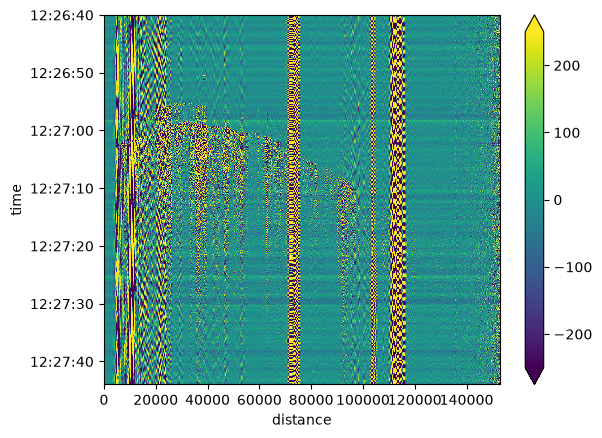

In [9]:
resampled = xd.resample(da, interval=245.12, snap=True, dim="distance")  # 16 -> 1
resampled = xd.resample(resampled, 20, dim="time")  # 62.5 Hz -> 20 Hz

resampled.plot(yincrease=False, vmin=-250, vmax=250)

```{note}
`snap=True` keeps the output on the original sample grid, so the interval you
ask for is rounded to a whole number of input samples — 245.12 m is exactly
16 channels here. Without it, `xd.resample` looks for a rational ratio that
lands on what you asked: 62.5 Hz to 20 Hz above is 8 up, 25 down.
```

## An FK diagram

Nothing forces a data array to stay in time and distance. Here the two axes
are transformed and renamed on the way:

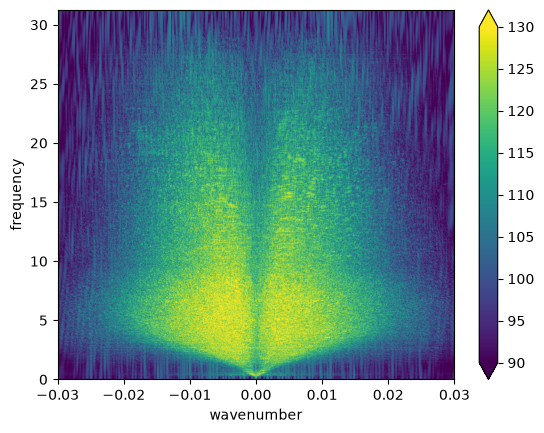

In [10]:
fk = da.sel(distance=slice(30_000, 70_000))
fk = xd.taper(fk, dim="distance")
fk = xd.taper(fk, dim="time")
fk = xd.fft.rfft(fk, dim={"time": "frequency"})  # rename "time" -> "frequency"
fk = xd.fft.fft(fk, dim={"distance": "wavenumber"})  # and "distance" -> "wavenumber"
fk = 20 * np.log10(np.abs(fk))

fk.plot(interpolation="antialiased", vmin=90, vmax=130, xlim=(-0.03, 0.03))

## From strain rate to velocity

The instrument records strain rate per unit length. Integrating along the
cable gives a deformation rate, from which a sliding mean is removed to
suppress the very long wavelengths the integration amplifies:

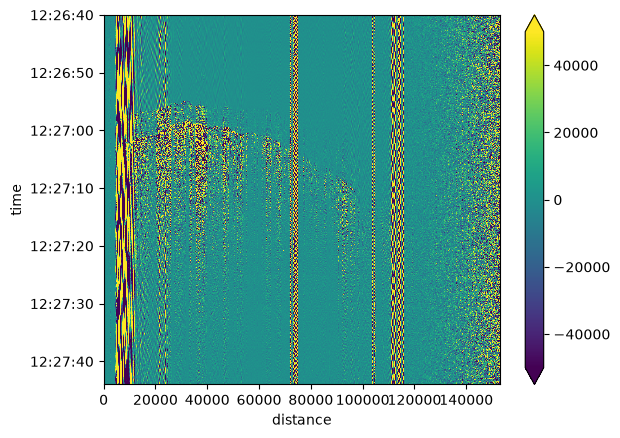

In [11]:
deformation = xd.integrate(da, dim="distance")
velocity = xd.sliding_mean_removal(deformation, wlen=1000.0, dim="distance")

velocity.plot(yincrease=False, vmin=-50_000, vmax=50_000)

Note that `wlen=1000.0` is a thousand *metres*, because the dimension is
distance. On the time axis the very same call would read seconds.